In [8]:
# Setup: Add repository to path for importing custom modules
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent
sys.path.append(str(repo_root))

In [2]:
# Import custom modules
from scripts.db_utils import fetch_ids
from scripts.motion_features import summarize_speed_from_ids
from scripts.feature_barplot import barplot_mean_se

ChickenBroth-Saline: [22.90094528527042, 8.220388711860465, 9.988925570742976, 7.462134938587023, 28.730941510186284, 17.427583953096715, 15.921474414879446, 24.309524323229503, 48.318953200726675, 40.16232223432178, 37.801650474515576, 30.779159025836908, 40.02237359884019, 38.549900571291175, 32.37159278784344, 25.898981299747657, 47.34127000822342, 40.373672969055654, 36.5601803387406, 34.278289856100415, 54.00359471585836, 49.68656354434358, 51.331865126090015, 47.55758131166918, 72.96264812400523, 61.50823902062026, 68.08668370933975, 76.71917285388035, 37.95548264954803, 27.98351553796367, 34.252853013944396, 31.222083407549064, 52.56161282602297, 69.72066731258394, 67.81652787906097, 71.42466760210793, 37.28620678603522, 15.696316368691424, 24.549341481908275, 16.017881781501828, 23.9118339697141, 12.539457342147317, 12.636039401073926, 11.424957069650361, 63.267806790524, 50.57553409688987, 44.39992101818348, 34.91382385054373, 46.30202436154526, 35.03918526397126, 25.017459617

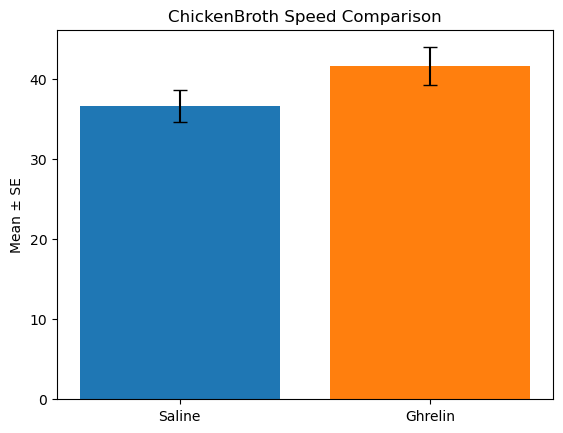

In [7]:
# ChickenBroth task: Compare speed between Saline (Y) and Ghrelin (P) treatments
query1 = "SELECT id FROM experimental_metadata WHERE task = 'ChickenBroth' AND treatment = 'Y';"
query2 = "SELECT id FROM experimental_metadata WHERE task = 'ChickenBroth' AND treatment = 'P';"

ids_y = fetch_ids(query1)
ids_p = fetch_ids(query2)

speed_y = summarize_speed_from_ids(ids_y)
speed_p = summarize_speed_from_ids(ids_p)

# print("ChickenBroth-Saline:", speed_y)
# print("ChickenBroth-Ghrelin:", speed_p)


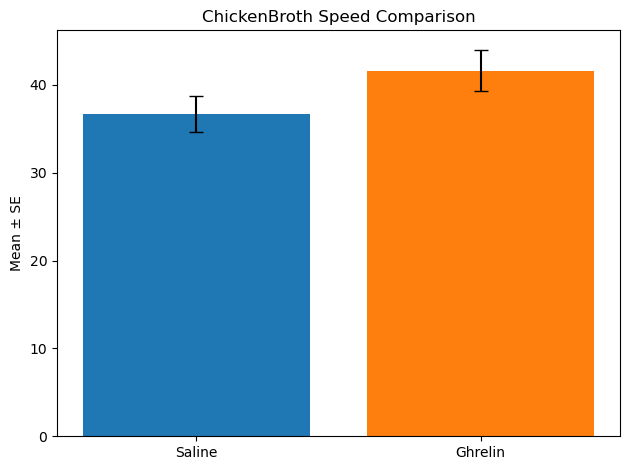

In [9]:
results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

barplot_mean_se(
    speed_y,
    speed_p,
    labels=["Saline", "Ghrelin"]
)

import matplotlib.pyplot as plt
plt.title("ChickenBroth Speed Comparison")
plt.tight_layout()
plt.savefig(results_dir / "chickenbroth_speed.png", dpi=300, bbox_inches="tight")
plt.show()